# Project 3: Anomaly Detection in a Financial Dataset

**Authors:** Abigail Keegan, Michelle Ng Du

**Course:** CS 667 Practical Data Science, Pace University

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib_venn import venn2
from sklearn.model_selection import ParameterGrid
from sklearn import preprocessing
from sklearn.ensemble import IsolationForest
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve,
    classification_report
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')


This project applies two unsupervised anomaly detection methods to a financial transactions dataset: a Gaussian Mixture Model (GMM) and an Isolation Forest. The dataset contains 216,960 transactions across 15 accounts. Because the dataset has no fraud labels, 2,000 synthetic anomalies are added so the models can be evaluated. Each account is described by a set of engineered features covering merchant, location, and transaction type usage, along with the transaction amount and several rolling time-based features. Both models are trained on the normal transactions only and tested on a mix of normal and anomalous data.

## Data Preparation

In [2]:
# Look at first 5 rows
df = pd.read_csv('../data/financial_anomaly_data.csv')
print("=== Head ===")
print(df.head())

=== Head ===
          Timestamp TransactionID AccountID    Amount   Merchant  \
0  2023-01-01 08:00       TXN1127      ACC4  95071.92  MerchantH   
1  2023-01-01 08:01       TXN1639     ACC10  15607.89  MerchantH   
2  2023-01-01 08:02        TXN872      ACC8  65092.34  MerchantE   
3  2023-01-01 08:03       TXN1438      ACC6     87.87  MerchantE   
4  2023-01-01 08:04       TXN1338      ACC6    716.56  MerchantI   

  TransactionType     Location  
0        Purchase        Tokyo  
1        Purchase       London  
2      Withdrawal       London  
3        Purchase       London  
4        Purchase  Los Angeles  


In [3]:
# Get info on features
print("=== Info ===")
print(df.info())

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216960 entries, 0 to 216959
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Timestamp        216960 non-null  object 
 1   TransactionID    216960 non-null  object 
 2   AccountID        216960 non-null  object 
 3   Amount           216960 non-null  float64
 4   Merchant         216960 non-null  object 
 5   TransactionType  216960 non-null  object 
 6   Location         216960 non-null  object 
dtypes: float64(1), object(6)
memory usage: 11.6+ MB
None


In [4]:
# Get count of distinct values in each column
print(f'Unique Merchants: {len(df['Merchant'].unique())}')
print(f'Unique TransactionIDs: {len(df['TransactionID'].unique())}')
print(f'Unique AccountIDs: {len(df['AccountID'].unique())}')
print(f'Unique TransactionTypes: {len(df['TransactionType'].unique())}')
print(f'Unique Locations: {len(df['Location'].unique())}')

Unique Merchants: 10
Unique TransactionIDs: 1999
Unique AccountIDs: 15
Unique TransactionTypes: 3
Unique Locations: 5


In [5]:
# Get basic summary statistics
print("\n=== Describe ===")
print(df.describe())


=== Describe ===
              Amount
count  216960.000000
mean    50090.025108
std     29097.905016
min        10.510000
25%     25061.242500
50%     50183.980000
75%     75080.460000
max    978942.260000


In [6]:
# Check for missingness / null values
print("\n=== Null Counts ===")
df.isnull().sum()


=== Null Counts ===


,0
Timestamp,0
TransactionID,0
AccountID,0
Amount,0
Merchant,0
TransactionType,0
Location,0


In [7]:
# Simplify Merchant and AccountID for cleaner downstream output
df['Merchant'] = df['Merchant'].astype(str).str[-1]
df['AccountID'] = df['AccountID'].astype(str).str.replace('ACC', '', regex=False)

#### Timestamp formatting

---

##### To properly handle Timestamp, a regex function was used to find the different patterns available in the dataset. Then, those patterns were used to normalize timestamps.

In [8]:
# Replace all digits in 'Timestamp' with 'D' and print unique date patterns
def patternize(x):
    return re.sub(r'\d', 'D', x)

s = df['Timestamp'].astype(str)
unique_patterns = s.map(patternize).unique()

for p in unique_patterns:
    print(p)

DDDD-DD-DD DD:DD
DD-DD-DDDD DD:DD


In [9]:
# Convert 'Timestamp' to uniform datetime objects
s = df['Timestamp']

df['Timestamp'] = pd.to_datetime(
    s.where(s.str.contains(r'^\d{4}-\d{2}-\d{2} \d{2}:\d{2}$'), None),
    format='%Y-%m-%d %H:%M',
    errors='coerce'
).fillna(
    pd.to_datetime(s, format='%d-%m-%Y %H:%M', errors='coerce')
)

In [10]:
# Extract temporal features
df['Month']     = df['Timestamp'].dt.month
df['MonthName'] = df['Timestamp'].dt.month_name()

# Get date range
print(f"\nDate range: {df['Timestamp'].min().date()} to {df['Timestamp'].max().date()}")



Date range: 2023-01-01 to 2023-12-05


In [11]:
# Scale 'Amount' with both methods for reference; use MinMax downstream
# to match the frequency-encoded features
sscaler = preprocessing.StandardScaler()
df['S_Amount'] = sscaler.fit_transform(df[['Amount']])

mscaler_amt = preprocessing.MinMaxScaler()
df['MM_Amount'] = mscaler_amt.fit_transform(df[['Amount']])

#### Rolling and Behavioral Features

Several features are added to capture how each account behaves over time:
* the time since the previous transaction,
* the number of transactions in the last 10 minutes,
* the rolling mean and standard deviation of the last 20 transaction amounts
* a flag for when an account's location changes between transactions.

These features help the models notice short-term changes in spending behavior that the overall frequency counts would miss.

In [12]:
# Sort by Timestamp
df = df.sort_values('Timestamp').reset_index(drop=True)

if df.index.name == 'Timestamp':
    df = df.reset_index()

# Elapsed time between transactions for each account
df['elapsed_time'] = df.groupby('AccountID')['Timestamp'].diff().dt.total_seconds()
df['elapsed_time'] = df['elapsed_time'].fillna(0)

df = df.set_index('Timestamp')

# 10-minute rolling transaction count per account
df['rolling_count_10min'] = (
    df.groupby('AccountID')['Amount']
      .rolling('10min')
      .count()
      .reset_index(level=0, drop=True)
)

# 20-transaction rolling mean and std of Amount per account
window = 20
df['rolling_mean_amt'] = df.groupby('AccountID')['Amount'].transform(
    lambda x: x.rolling(window).mean()
)
df['rolling_std_amt'] = df.groupby('AccountID')['Amount'].transform(
    lambda x: x.rolling(window).std()
)

# Location change flag
df['prev_location'] = df.groupby('AccountID')['Location'].shift()
df['location_changed'] = (
    (df['Location'] != df['prev_location']) & df['prev_location'].notna()
).astype(int)

# Fill NaNs from incomplete rolling windows at the start of each account's history.
# Backfill rolling_mean_amt within account so early rows get the account's first
# valid mean. Fill rolling_std_amt with 0 (there is no variance observed yet.)
df['rolling_mean_amt'] = df.groupby('AccountID')['rolling_mean_amt'].transform(
    lambda x: x.bfill().fillna(0)
)
df['rolling_std_amt'] = df['rolling_std_amt'].fillna(0)

# Drop helper column
df = df.drop(columns=['prev_location'])

In [13]:
print(df.head())

                    TransactionID AccountID    Amount Merchant  \
Timestamp                                                        
2023-01-01 08:00:00       TXN1127         4  95071.92        H   
2023-01-01 08:01:00       TXN1639        10  15607.89        H   
2023-01-01 08:02:00        TXN872         8  65092.34        E   
2023-01-01 08:03:00       TXN1438         6     87.87        E   
2023-01-01 08:04:00       TXN1338         6    716.56        I   

                    TransactionType     Location  Month MonthName  S_Amount  \
Timestamp                                                                     
2023-01-01 08:00:00        Purchase        Tokyo      1   January  1.545884   
2023-01-01 08:01:00        Purchase       London      1   January -1.185041   
2023-01-01 08:02:00      Withdrawal       London      1   January  0.515582   
2023-01-01 08:03:00        Purchase       London      1   January -1.718415   
2023-01-01 08:04:00        Purchase  Los Angeles      1   Janua

#### Frequency Encoding by Account

To measure how often each account uses a given merchant, location, or transaction type, the data is grouped by `AccountID` and the relevant categories are counted. Counts are also computed for each month and for pairs of categories.

In [14]:
# Frequency encoding for feature engineering
enc_columns = ['Merchant', 'Location', 'TransactionType']
enc_df = df.copy()

for i, col in enumerate(enc_columns):
    col_name = col + '_enc'
    enc_df[col_name] = enc_df.groupby(['AccountID', col])[col].transform('count')

    col_name_month = col_name + '_month_enc'
    enc_df[col_name_month] = enc_df.groupby(['AccountID', 'MonthName', col])[col].transform('count')

    n = i + 1
    while n < len(enc_columns):
        pair_col = col + '_' + enc_columns[n] + '_enc'
        temp = enc_df.groupby(['AccountID', col, enc_columns[n]])[[col, enc_columns[n]]].transform('count')
        enc_df[pair_col] = temp.iloc[:, 0]
        n += 1

# Frequency-encoded features
freq_cols = [
    'Merchant_enc', 'Merchant_enc_month_enc', 'Merchant_Location_enc',
    'Merchant_TransactionType_enc', 'Location_enc', 'Location_TransactionType_enc',
    'TransactionType_enc', 'Location_enc_month_enc', 'TransactionType_enc_month_enc'
]

# Amount-derived and rolling features
extra_cols = [
    'MM_Amount', 'elapsed_time', 'rolling_count_10min',
    'rolling_mean_amt', 'rolling_std_amt', 'location_changed'
]

# Full feature set
acc_cols = freq_cols + extra_cols

#### Injected Anomalies and Normalization

The dataset has no fraud labels, so 2,000 synthetic anomalies are added to support evaluation. This brings the anomaly rate to roughly 1%. Features are first scaled to the [0, 1] range. The synthetic rows are then created by taking real rows and shifting two of their features well outside that range, producing clearly unusual examples.

In [15]:
# Normalize frequency-encoded features as a rate per AccountID
acc_count = enc_df.groupby('AccountID').size().reset_index(name='Count')
counts    = acc_count.set_index('AccountID')

for col in freq_cols:
    rate   = enc_df[col] / enc_df['AccountID'].map(counts['Count'])
    scaler = preprocessing.MinMaxScaler()
    enc_df[col] = scaler.fit_transform(rate.to_frame())

# Scale rolling and elapsed-time features to [0, 1].
# MM_Amount is already [0, 1] from cell 13; location_changed is already binary.
rolling_to_scale = ['elapsed_time', 'rolling_count_10min',
                    'rolling_mean_amt', 'rolling_std_amt']

for col in rolling_to_scale:
    scaler = preprocessing.MinMaxScaler()
    enc_df[col] = scaler.fit_transform(enc_df[[col]])

In [16]:
# Inject synthetic anomalies
enc_col = acc_cols
X = enc_df[enc_col].copy()

def synthetic_anomalies(d, n, random_state=42):
    rng = np.random.default_rng(random_state)
    rows = []
    for _ in range(n):
        row = d.sample(1, random_state=int(rng.integers(0, 1_000_000))).iloc[0].copy()
        cols_to_modify = rng.choice(d.columns, size=2, replace=False)
        for c in cols_to_modify:
            row[c] += rng.choice([-1, 1]) * rng.uniform(2.5, 4)
        rows.append(row)
    return pd.DataFrame(rows)

syn_rows = synthetic_anomalies(X, 2000)
syn_rows['Anomaly'] = 1

X['Anomaly'] = 0
X_2 = pd.concat([X, syn_rows], ignore_index=True)

print(f"Dataset shape with synthetic anomalies: {X_2.shape}")
print(f"Synthetic anomalies injected: {int(X_2['Anomaly'].sum())}")
print(f"Contamination rate: {X_2['Anomaly'].mean():.4f}")
print(f"Total features: {len(enc_col)}")

Dataset shape with synthetic anomalies: (218960, 16)
Synthetic anomalies injected: 2000
Contamination rate: 0.0091
Total features: 15


In [17]:
print(X_2.head(5))
print(X_2.tail(5))

   Merchant_enc  Merchant_enc_month_enc  Merchant_Location_enc  \
0      0.455484                0.839638               0.370870   
1      0.491271                0.879745               0.478502   
2      0.767245                0.898086               0.653622   
3      0.739890                0.897380               0.599215   
4      0.643828                0.905851               0.526039   

   Merchant_TransactionType_enc  Location_enc  Location_TransactionType_enc  \
0                      0.241206      0.568583                      0.615844   
1                      0.143389      0.505570                      0.167297   
2                      0.512962      0.328099                      0.406144   
3                      0.728919      0.434274                      0.232934   
4                      0.469768      1.000000                      0.588441   

   TransactionType_enc  Location_enc_month_enc  TransactionType_enc_month_enc  \
0             0.441838                0.896576 

## Model Building

---

#### Isolation Forest

The Isolation Forest is tuned using a grid search across four parameters: the number of trees, the sample size per tree, the expected anomaly rate, and the number of features considered at each split. Each combination is trained on normal transactions only and scored on a held-out test set using PR-AUC. The best combination is then used for the final model.

In [18]:
# Train/test split for anomaly detection
normal_pool  = X_2[X_2['Anomaly'] == 0].reset_index(drop=True)
anomaly_pool = X_2[X_2['Anomaly'] == 1].reset_index(drop=True)

X_train_full = normal_pool.sample(n=10000, random_state=42)
X_train = X_train_full[acc_cols]

remaining_normals = normal_pool.drop(X_train_full.index)
test_normals = remaining_normals.sample(n=8000, random_state=42)

test_df = pd.concat([test_normals, anomaly_pool], ignore_index=True)
X_test = test_df[acc_cols]
y_test = test_df['Anomaly'].astype(int)

print(f"Features used: {len(acc_cols)}")
print(f"Train shape: {X_train.shape} (all normal)")
print(f"Test shape:  {X_test.shape} ({y_test.sum()} anomalies, "
      f"{(y_test == 0).sum()} normals)")
print(f"Test contamination: {y_test.mean():.4f}")

# Grid search
param_grid = {
    'n_estimators':  [50, 100, 150],
    'max_samples':   [0.3, 0.6],
    'contamination': [0.005, 0.01, 0.05],
    'max_features':  [3, 5, 7],
}

best_score = -np.inf
best_params = None
results = []

for params in ParameterGrid(param_grid):
    iforest = IsolationForest(random_state=42, **params)
    iforest.fit(X_train)
    scores = -iforest.decision_function(X_test)
    ap = average_precision_score(y_test, scores)
    results.append({**params, 'pr_auc': ap})

    if ap > best_score:
        best_score = ap
        best_params = params

results_df = pd.DataFrame(results).sort_values('pr_auc', ascending=False)
print(f"\nBest PR-AUC on holdout: {best_score:.4f}")
print(f"Best params: {best_params}")
print("\nTop 5 configurations:")
print(results_df.head().to_string(index=False))

Features used: 15
Train shape: (10000, 15) (all normal)
Test shape:  (10000, 15) (2000 anomalies, 8000 normals)
Test contamination: 0.2000

Best PR-AUC on holdout: 0.7596
Best params: {'contamination': 0.005, 'max_features': 7, 'max_samples': 0.6, 'n_estimators': 150}

Top 5 configurations:
 contamination  max_features  max_samples  n_estimators   pr_auc
         0.005             7          0.6           150 0.759601
         0.010             7          0.6           150 0.759601
         0.050             7          0.6           150 0.759601
         0.050             3          0.6           150 0.755218
         0.010             3          0.6           150 0.755218


In [19]:
# Fit the best Isolation Forest on the normal-only training set
iforest = IsolationForest(random_state=42, **best_params)
iforest.fit(X_train)

IsolationForest(contamination=0.005, max_features=7, max_samples=0.6,
                n_estimators=150, random_state=42)

#### Gaussian Mixture Model

The Gaussian Mixture Model represents normal behavior as a mix of several overlapping clusters. The number of clusters is chosen using BIC and AIC, two standard scoring methods that balance fit against complexity. After fitting, each transaction receives a log-likelihood score; transactions with very low likelihood are flagged as anomalies.

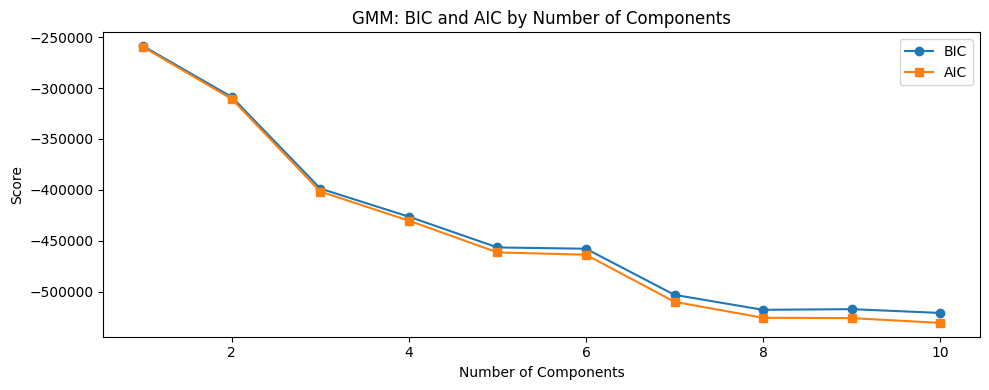


Optimal number of components (BIC): 10
Optimal number of components (AIC): 10


GaussianMixture(n_components=10, random_state=42)

In [20]:
# Fit GMM on the same normal-only training set used for Isolation Forest
X_GMM_train = X_train

# Select optimal number of components via BIC/AIC
bic_scores = []
aic_scores = []
n_components_range = range(1, 11)

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=42)
    gmm.fit(X_GMM_train)
    bic_scores.append(gmm.bic(X_GMM_train))
    aic_scores.append(gmm.aic(X_GMM_train))

plt.figure(figsize=(10, 4))
plt.plot(n_components_range, bic_scores, label='BIC', marker='o')
plt.plot(n_components_range, aic_scores, label='AIC', marker='s')
plt.xlabel('Number of Components')
plt.ylabel('Score')
plt.title('GMM: BIC and AIC by Number of Components')
plt.legend()
plt.tight_layout()
plt.show()

best_n     = list(n_components_range)[np.argmin(bic_scores)]
best_n_aic = list(n_components_range)[np.argmin(aic_scores)]
print(f"\nOptimal number of components (BIC): {best_n}")
print(f"Optimal number of components (AIC): {best_n_aic}")

gmm_model = GaussianMixture(n_components=best_n, covariance_type='full', random_state=42)
gmm_model.fit(X_GMM_train)

In [21]:
# Score the full dataset (original + synthetic)
X_2_score = X_2[acc_cols].reset_index(drop=True)

# Isolation Forest
if_predictions = iforest.predict(X_2_score)
if_scores      = iforest.decision_function(X_2_score)
if_flags       = (if_predictions == -1).astype(int)

# GMM: flag the lowest 1% of log-likelihoods (matching ~0.91% contamination)
gmm_log_likelihood = gmm_model.score_samples(X_2_score)
threshold_gmm      = np.percentile(gmm_log_likelihood, 1)
gmm_flags          = (gmm_log_likelihood < threshold_gmm).astype(int)

true_labels = X_2['Anomaly'].reset_index(drop=True)

eval_df = pd.DataFrame({
    'true_label':    true_labels,
    'iforest_flag':  if_flags,
    'iforest_score': if_scores,
    'gmm_flag':      gmm_flags,
    'gmm_log_lik':   gmm_log_likelihood
}).dropna()

print(f"Eval DataFrame shape: {eval_df.shape}")
print("\nLabel distribution:")
print(eval_df['true_label'].astype(int).value_counts())
print(f"\nIF anomalies flagged:  {eval_df['iforest_flag'].sum()}")
print(f"GMM anomalies flagged: {eval_df['gmm_flag'].sum()}")

threshold_if = eval_df.loc[eval_df['iforest_flag'] == 0, 'iforest_score'].min()
print(f"\nIF anomaly score threshold:   {threshold_if:.4f}")
print(f"GMM log-likelihood threshold: {threshold_gmm:.4f}")

Eval DataFrame shape: (218960, 5)

Label distribution:
true_label
0    216960
1      2000
Name: count, dtype: int64

IF anomalies flagged:  2160
GMM anomalies flagged: 2190

IF anomaly score threshold:   0.0000
GMM log-likelihood threshold: -51.4061


In [22]:
# Evaluation metrics

def eval_metrics(name, y_true, y_pred, y_score):
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  F1-Score  : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_true, y_score):.4f}")
    print(f"  PR-AUC    : {average_precision_score(y_true, y_score):.4f}")

eval_metrics("Isolation Forest",
             eval_df['true_label'], eval_df['iforest_flag'], -eval_df['iforest_score'])

eval_metrics("Gaussian Mixture Model",
             eval_df['true_label'], eval_df['gmm_flag'], -eval_df['gmm_log_lik'])


  Isolation Forest
  Precision : 0.2630
  Recall    : 0.2840
  F1-Score  : 0.2731
  ROC-AUC   : 0.9135
  PR-AUC    : 0.1994

  Gaussian Mixture Model
  Precision : 0.9132
  Recall    : 1.0000
  F1-Score  : 0.9547
  ROC-AUC   : 0.9996
  PR-AUC    : 0.9298


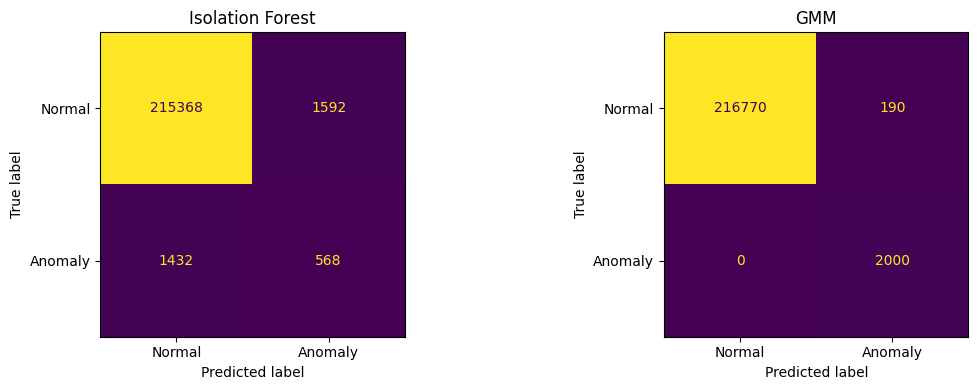

In [23]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, name, y_pred in zip(axes,
                             ['Isolation Forest', 'GMM'],
                             [eval_df['iforest_flag'], eval_df['gmm_flag']]):
    cm = confusion_matrix(eval_df['true_label'], y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Anomaly'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

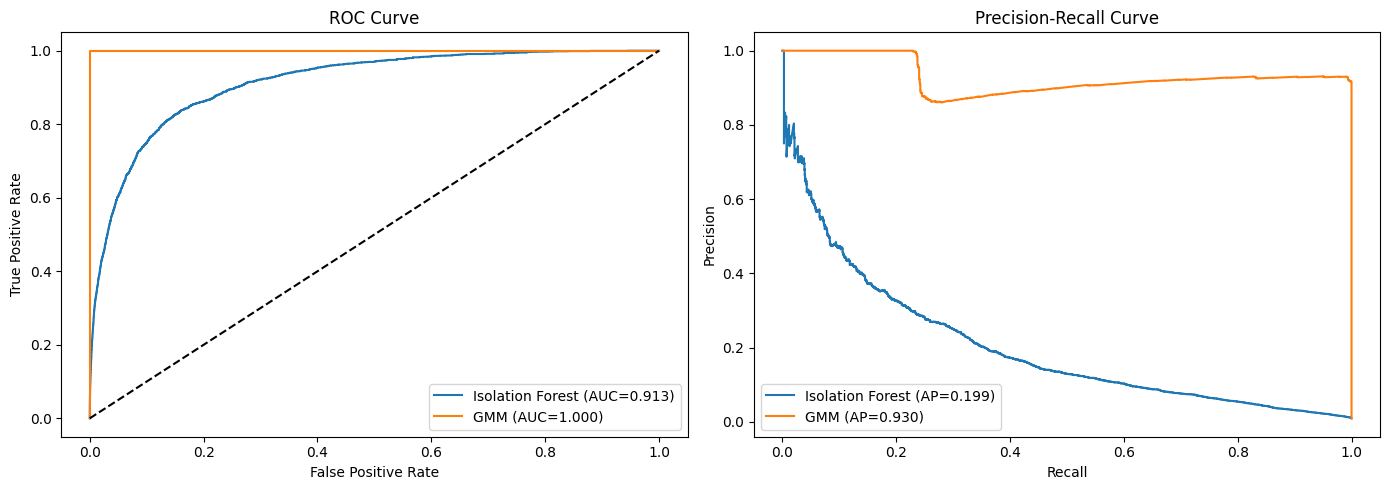

In [24]:
# ROC and Precision Recall
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, score in [('Isolation Forest', -eval_df['iforest_score']),
                    ('GMM',              -eval_df['gmm_log_lik'])]:
    fpr, tpr, _ = roc_curve(eval_df['true_label'], score)
    auc = roc_auc_score(eval_df['true_label'], score)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

for name, score in [('Isolation Forest', -eval_df['iforest_score']),
                    ('GMM',              -eval_df['gmm_log_lik'])]:
    prec, rec, _ = precision_recall_curve(eval_df['true_label'], score)
    ap = average_precision_score(eval_df['true_label'], score)
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

**Isolation Forest** performs noticeably worse than GMM on this dataset, with a PR-AUC of 0.199 and an F1 of 0.273. Although it still achieves a strong ROC-AUC of 0.914, its precision and recall at the chosen threshold are both below 0.30, meaning it flags many normal transactions while missing most synthetic anomalies. The high ROC-AUC paired with low PR-AUC is a classic pattern when anomalies are rare: the model ranks anomalies reasonably well on average, but cannot pick a threshold that cleanly separates them from normal points.

**GMM** performs strongly across the board, with a precision of 0.913, perfect recall of 1.000, an F1 of 0.955, ROC-AUC of 1.000, and PR-AUC of 0.930. The synthetic anomalies sit far outside the bulk of the normal distribution, which translates directly into very low log-likelihood scores that the GMM can flag cleanly.

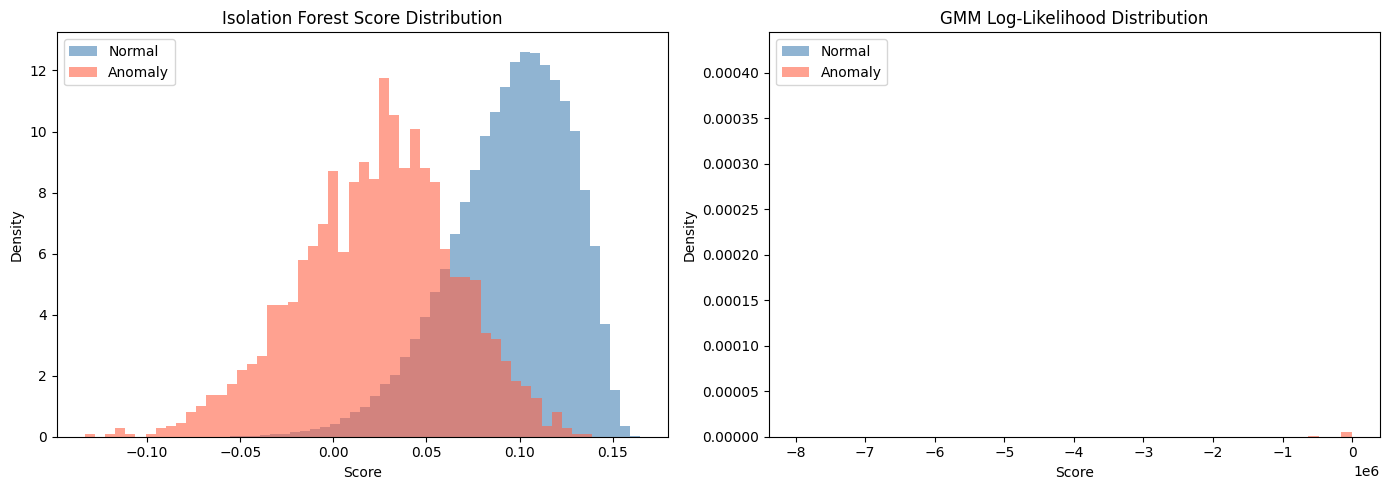

In [25]:
# Anomaly score distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, score_col in [
        (axes[0], 'Isolation Forest Score', 'iforest_score'),
        (axes[1], 'GMM Log-Likelihood',     'gmm_log_lik')]:
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        subset = eval_df[eval_df['true_label'] == label][score_col]
        ax.hist(subset, bins=50, alpha=0.6, color=color,
                label='Normal' if label == 0 else 'Anomaly', density=True)
    ax.set_title(f'{name} Distribution')
    ax.set_xlabel('Score')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

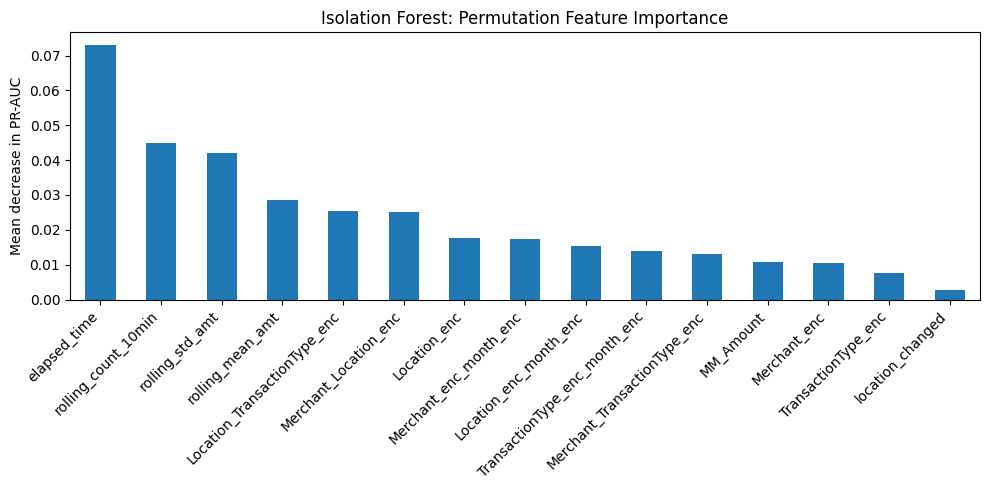


Top features by importance:
elapsed_time                     0.072996
rolling_count_10min              0.044789
rolling_std_amt                  0.041943
rolling_mean_amt                 0.028605
Location_TransactionType_enc     0.025340
Merchant_Location_enc            0.025132
Location_enc                     0.017556
Merchant_enc_month_enc           0.017416
Location_enc_month_enc           0.015268
TransactionType_enc_month_enc    0.013923
Merchant_TransactionType_enc     0.012993
MM_Amount                        0.010676
Merchant_enc                     0.010427
TransactionType_enc              0.007567
location_changed                 0.002746
dtype: float64


In [26]:
# Evaluation data
X_eval_arr = X_2[acc_cols].values
y_eval = eval_df['true_label'].values

# Custom scorer for anomaly detection
def ap_scorer(model, X, y):
    scores = -model.decision_function(X)   # higher = more anomalous
    return average_precision_score(y, scores)

perm = permutation_importance(iforest, X_eval_arr, y_eval, n_repeats=10,
                              random_state=42, scoring=ap_scorer)

feat_imp = pd.Series(perm.importances_mean, index=acc_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar')
plt.title("Isolation Forest: Permutation Feature Importance")
plt.ylabel("Mean decrease in PR-AUC")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop features by importance:")
print(feat_imp)

The rolling time-based features dominate the importance ranking for Isolation Forest. The top four features (elapsed_time, rolling_count_10min, rolling_std_amt, and rolling_mean_amt) all measure short-term spending behavior, and together they contribute more to anomaly ranking than the categorical aggregates. Among the categorical features, the cross-categorical pairs (Location_TransactionType and Merchant_Location) carry the most signal, while single-category counts like Merchant_enc and TransactionType_enc contribute the least. This suggests that *when* and *how often* a transaction occurs is more informative than *which* merchant or category it belongs to.


GMM Component Weights:
  Component 0: weight=0.0112
  Component 1: weight=0.0489
  Component 2: weight=0.0556
  Component 3: weight=0.0005
  Component 4: weight=0.1905
  Component 5: weight=0.1505
  Component 6: weight=0.2053
  Component 7: weight=0.3341
  Component 8: weight=0.0013
  Component 9: weight=0.0021

GMM Component Means:
   Merchant_enc  Merchant_enc_month_enc  Merchant_Location_enc  \
0        0.5230                  0.8198                 0.5202   
1        0.5163                  0.0905                 0.5255   
2        0.5137                  0.8248                 0.5292   
3        0.6899                  0.0986                 0.5086   
4        0.5130                  0.0921                 0.5255   
5        0.5187                  0.8239                 0.5312   
6        0.5121                  0.8240                 0.5225   
7        0.5084                  0.8228                 0.5221   
8        0.7023                  0.8479                 0.7727   
9   

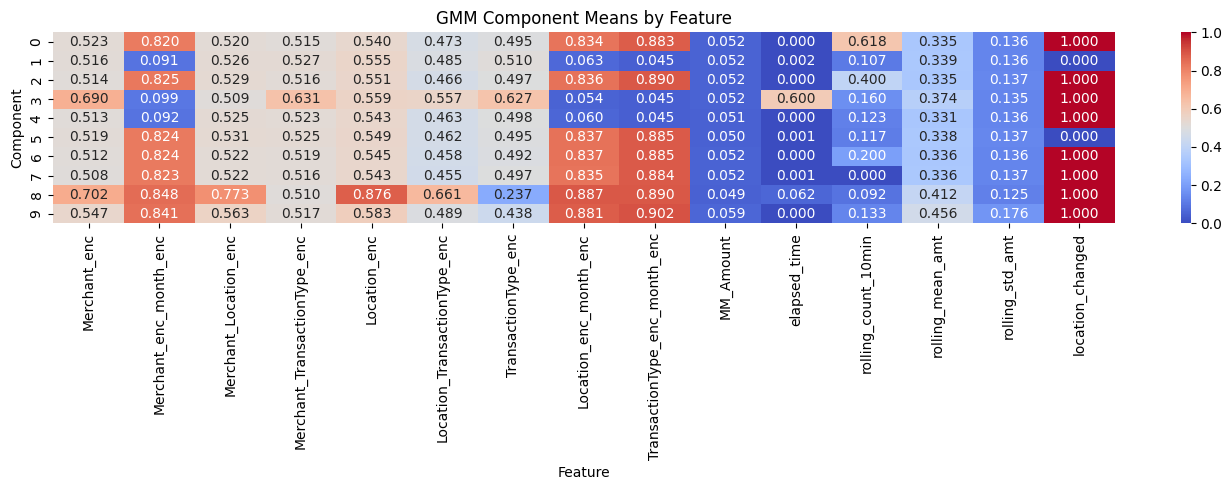

In [27]:
# GMM Components
print("\nGMM Component Weights:")
for i, w in enumerate(gmm_model.weights_):
    print(f"  Component {i}: weight={w:.4f}")

gmm_means_df = pd.DataFrame(gmm_model.means_, columns=acc_cols)
print("\nGMM Component Means:")
print(gmm_means_df.round(4))

plt.figure(figsize=(14, 5))
sns.heatmap(gmm_means_df, annot=True, fmt='.3f', cmap='coolwarm')
plt.title('GMM Component Means by Feature')
plt.xlabel('Feature')
plt.ylabel('Component')
plt.tight_layout()
plt.show()

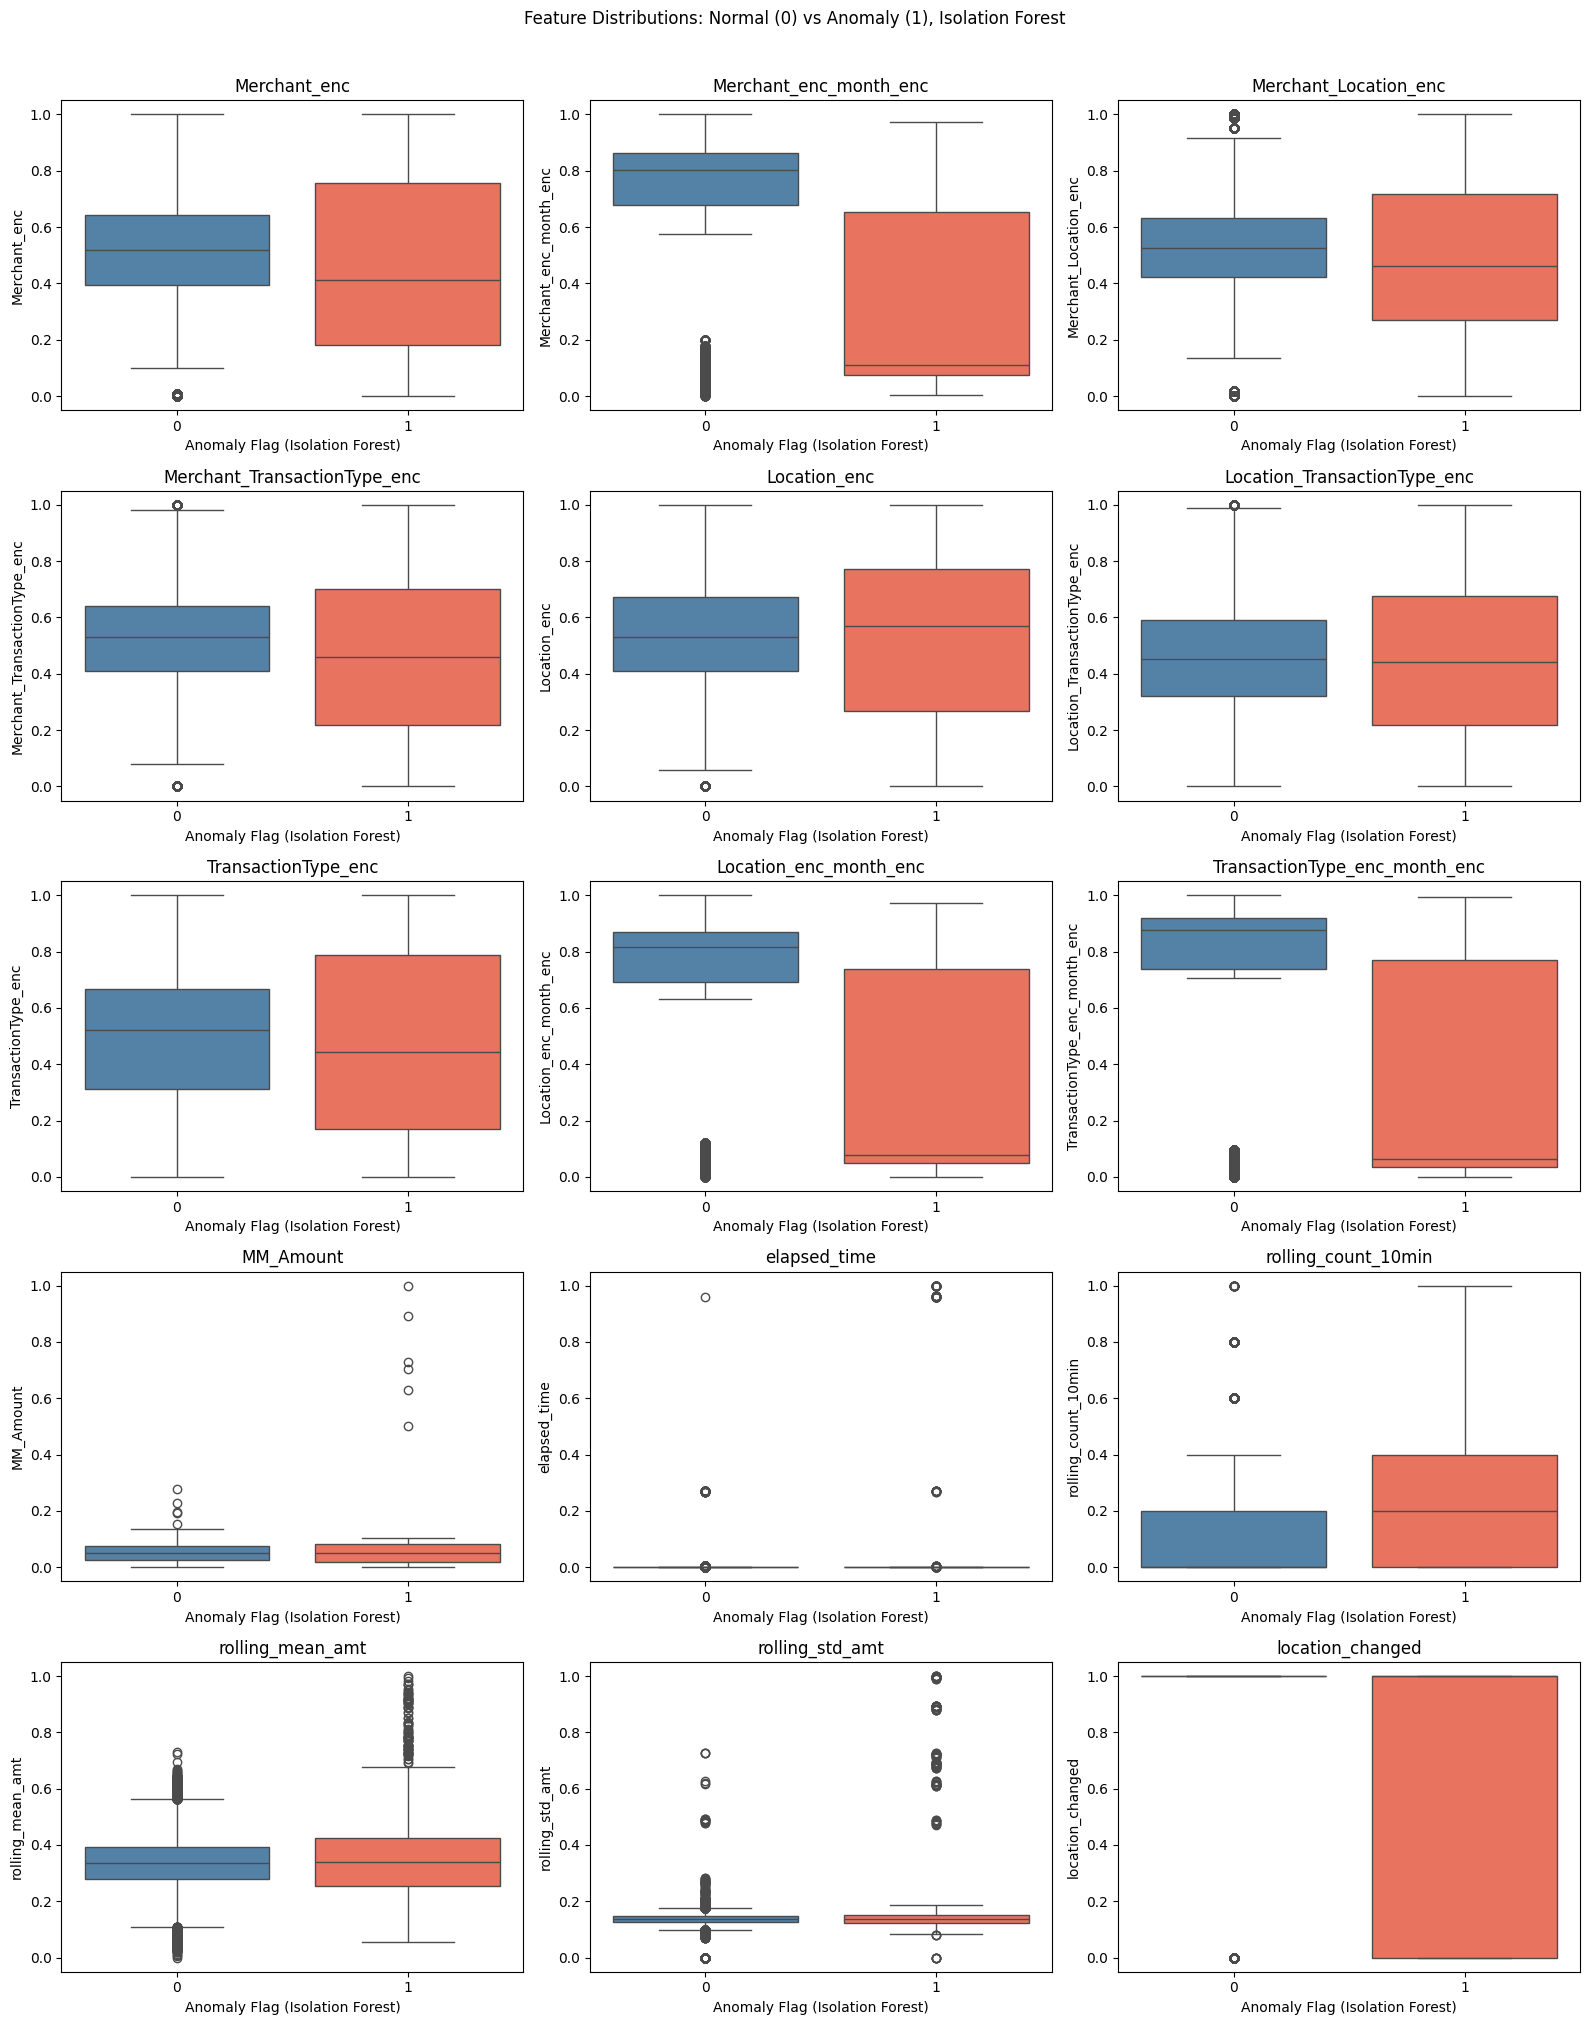

In [28]:
# Box Plots
X_vis = X[acc_cols].copy().reset_index(drop=True)
n_orig = len(X_vis)
X_vis['iforest_flag'] = if_flags[:n_orig].astype(int)
X_vis['gmm_flag']     = gmm_flags[:n_orig].astype(int)

n_features = len(acc_cols)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(acc_cols):
    sns.boxplot(data=X_vis, x='iforest_flag', y=col, ax=axes[i],
                palette=['steelblue', 'tomato'])
    axes[i].set_title(col)
    axes[i].set_xlabel('Anomaly Flag (Isolation Forest)')

for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions: Normal (0) vs Anomaly (1), Isolation Forest', y=1.01)
plt.tight_layout()
plt.show()

The anomalies flagged by Isolation Forest stand out most clearly on the monthly features: Merchant_enc_month_enc, Location_enc_month_enc, and TransactionType_enc_month_enc. This suggests that the timing of category usage is an important signal for spotting anomalies in this dataset.


PCA explained variance ratio: [0.36594109 0.18073309]


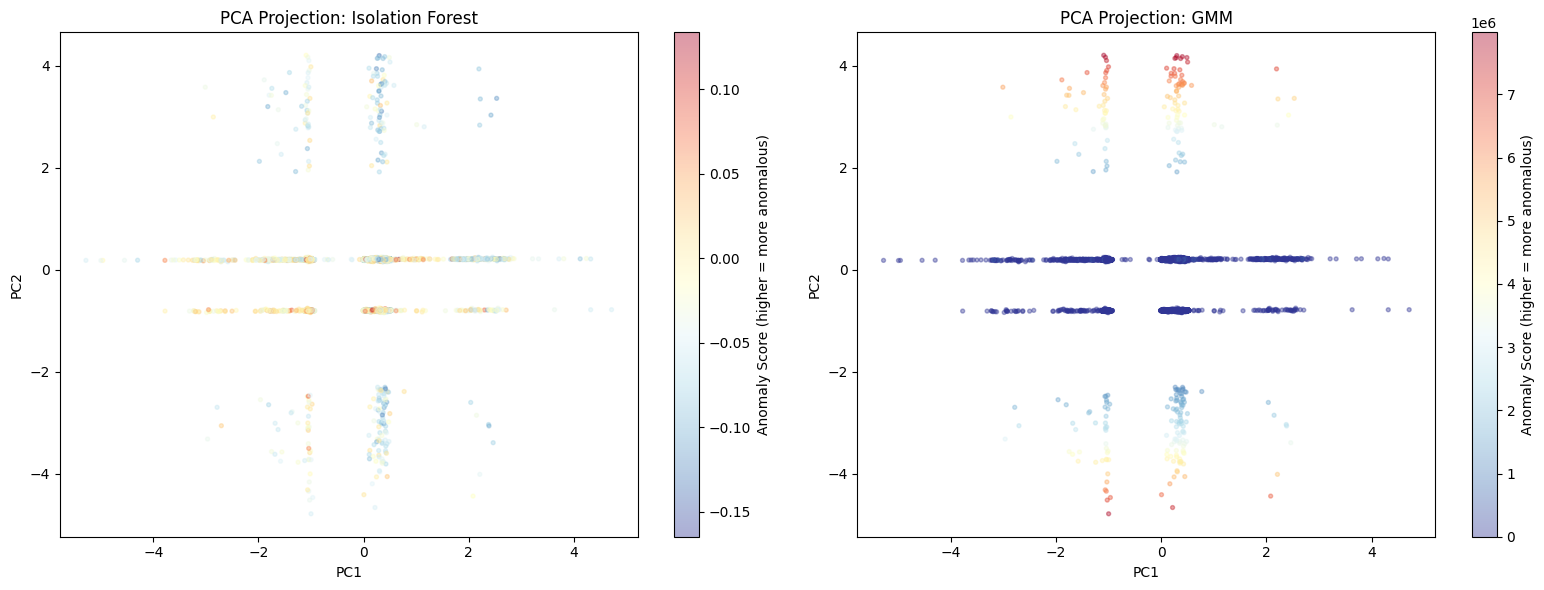

In [29]:
# PCA 2D Projection
X_pca_data = X_2[acc_cols]
pca        = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_pca_data)

# Align components with eval_df index
components_eval = components[eval_df.index]

print(f"\nPCA explained variance ratio: {pca.explained_variance_ratio_}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, name, scores in [
        (axes[0], 'Isolation Forest', -eval_df['iforest_score']),
        (axes[1], 'GMM',              -eval_df['gmm_log_lik'])]:
    sc = ax.scatter(components_eval[:, 0], components_eval[:, 1],
                    c=scores, cmap='RdYlBu_r', alpha=0.4, s=8)
    plt.colorbar(sc, ax=ax, label='Anomaly Score (higher = more anomalous)')
    ax.set_title(f'PCA Projection: {name}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')

plt.tight_layout()
plt.show()

In [30]:
# Check for Flagged Anomaly Overlap Between Models

if_anomalies  = set(eval_df[eval_df['iforest_flag'] == 1].index)
gmm_anomalies = set(eval_df[eval_df['gmm_flag'] == 1].index)

only_if  = if_anomalies - gmm_anomalies
only_gmm = gmm_anomalies - if_anomalies
both     = if_anomalies & gmm_anomalies

print(f"Flagged by IF only:  {len(only_if)}")
print(f"Flagged by GMM only: {len(only_gmm)}")
print(f"Flagged by both:     {len(both)}")

def summarize_group(label, idx):
    subset = eval_df.loc[list(idx)]
    tp = (subset['true_label'].astype(int) == 1).sum()
    fp = (subset['true_label'].astype(int) == 0).sum()
    print(f"\n{label} ({len(idx)} total): {tp} TP, {fp} FP")

summarize_group("IF only",  only_if)
summarize_group("GMM only", only_gmm)
summarize_group("Both",     both)

Flagged by IF only:  1464
Flagged by GMM only: 1494
Flagged by both:     696

IF only (1464 total): 0 TP, 1464 FP

GMM only (1494 total): 1432 TP, 62 FP

Both (696 total): 568 TP, 128 FP


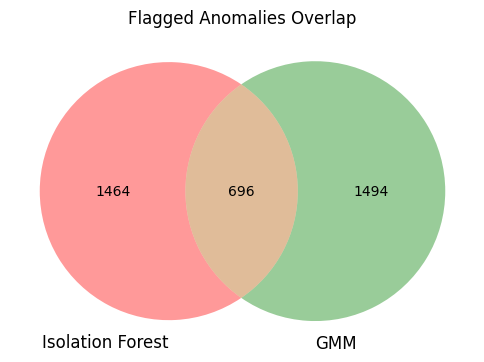

In [31]:
plt.figure(figsize=(6, 5))
venn2(
    subsets=(if_anomalies, gmm_anomalies),
    set_labels=('Isolation Forest', 'GMM')
)
plt.title('Flagged Anomalies Overlap')
plt.show()

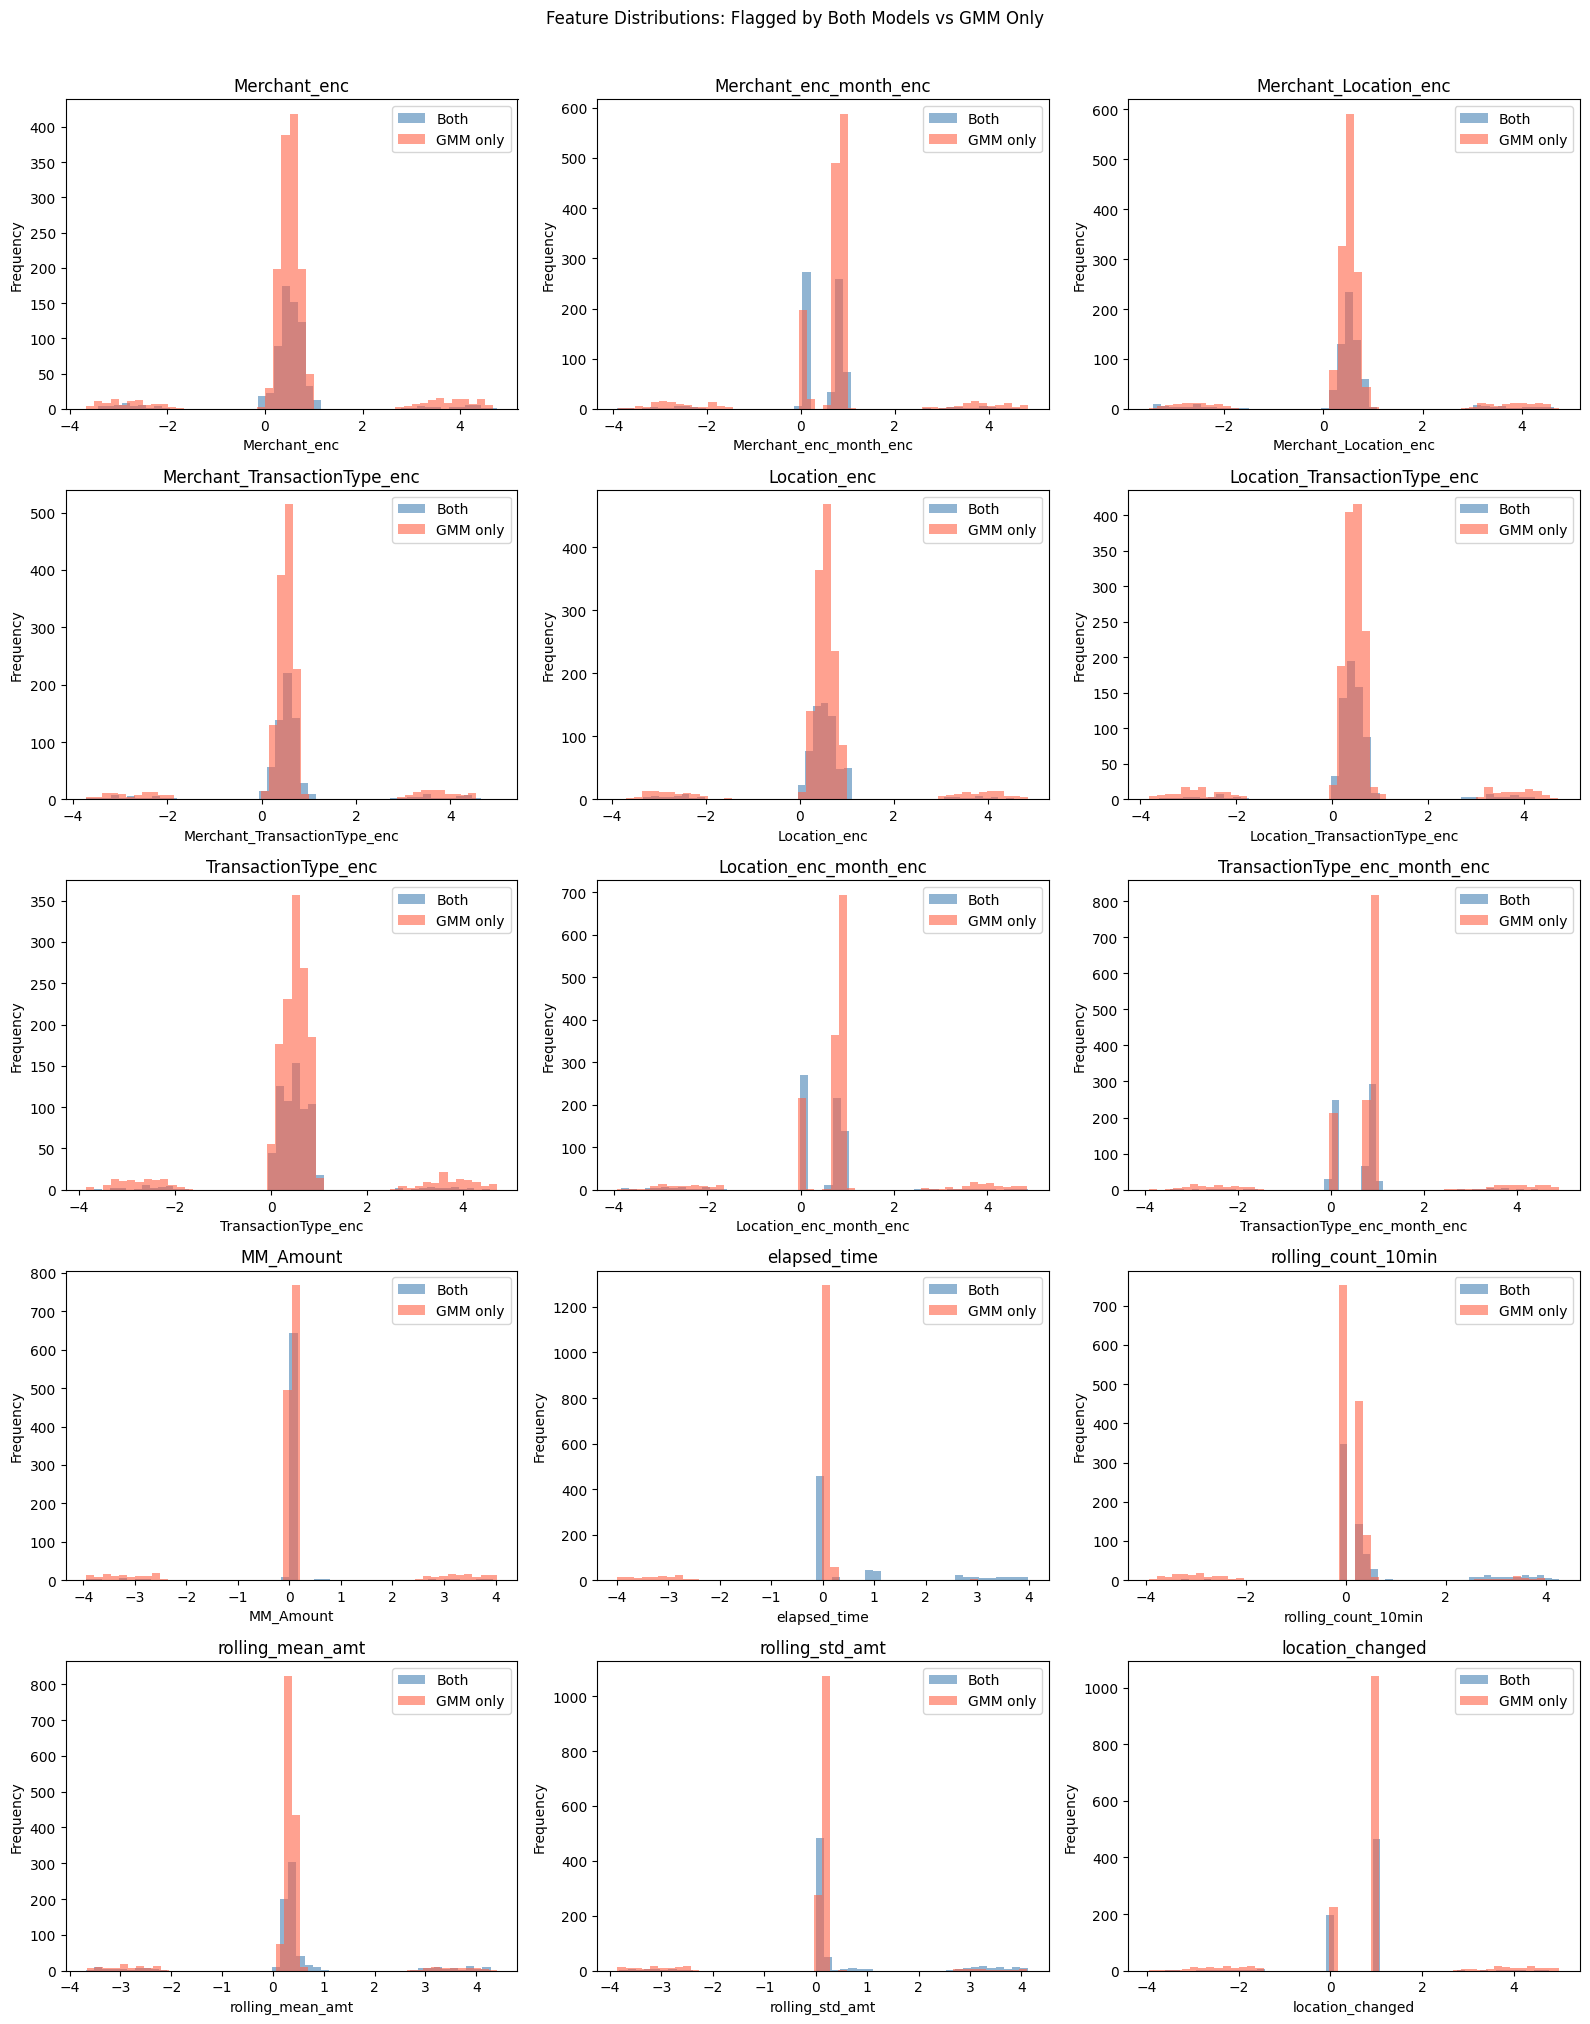

In [32]:
# Compare feature distributions for points flagged by both models
# vs points flagged only by GMM
only_gmm_df = X_2.loc[list(only_gmm), acc_cols]
both_df     = X_2.loc[list(both),     acc_cols]

n_features = len(acc_cols)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(acc_cols):
    axes[i].hist(both_df[col],     bins=50, alpha=0.6, color='steelblue', label='Both')
    axes[i].hist(only_gmm_df[col], bins=50, alpha=0.6, color='tomato',    label='GMM only')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions: Flagged by Both Models vs GMM Only', y=1.01)
plt.tight_layout()
plt.show()

The two models flag overlapping but largely different sets of transactions. They agree on 696 transactions (568 true positives, 128 false positives), but each model also flags a roughly equal-sized unique group: 1,464 from Isolation Forest only and 1,494 from GMM only. The two groups behave very differently. Every Isolation Forest only flag is a false positive, while 96% of GMM only flags are true positives. This confirms that GMM is doing most of the real work on this dataset, while Isolation Forest is largely picking up unrelated unusual patterns in the rolling features rather than the synthetic anomalies themselves.

## Interpretation and Insights

The dataset contains 216,960 financial transactions from January through December 2023, covering 15 accounts, 10 merchants, 3 transaction types, and 5 locations. Because the raw data has only one numeric column (Amount), additional features were created: nine frequency-encoded features capturing how often each account uses each merchant, location, and transaction type (overall, by month, and in pairs), the scaled transaction amount, and five rolling features describing short-term spending behavior, for 15 features total. All features were scaled to the [0, 1] range. Since the dataset has no fraud labels, 2,000 synthetic anomalies were added, giving a contamination rate of about 0.91%.

GMM was the stronger performer on this dataset. With 10 components selected by both BIC and AIC, the GMM reached a precision of 0.913, perfect recall of 1.000, an F1 of 0.955, ROC-AUC of 1.000, and PR-AUC of 0.930. The Isolation Forest, after grid search, reached a precision of 0.263, recall of 0.284, F1 of 0.273, ROC-AUC of 0.914, and PR-AUC of 0.199. The gap between the two models is largest on PR-AUC, which is the most informative metric when anomalies are rare. The overlap analysis is consistent with the metrics: the two models agreed on 696 transactions, but GMM caught an additional 1,494 that Isolation Forest missed (1,432 of which were true anomalies), while the 1,464 transactions flagged only by Isolation Forest were all false positives.

Some of the GMM's strong performance comes from how the synthetic anomalies were built. Shifting two features well outside the [0, 1] range pushes them into regions of very low log-likelihood under the fitted mixture, which makes them easy for GMM to detect. A real fraud dataset would likely be harder, with more subtle signals, so the GMM numbers should be read as an upper bound on what to expect in production. The Isolation Forest result is harder to read at face value: with only 15 features and a small number of anomaly types, the random feature splits seem to isolate normal but unusual rolling-feature patterns roughly as often as they isolate the synthetic anomalies, which drives precision down.

Inside the GMM, most normal transactions concentrate in three medium-large components: Component 7 (weight 0.334), Component 6 (weight 0.205), and Component 4 (weight 0.191), which together hold 73% of the probability mass and show balanced mid-range values across most features. These represent the bulk of typical recurring spending. Three sparse components (Component 3 at 0.0005, Component 8 at 0.0013, and Component 9 at 0.0021) together hold under 0.5% of the probability mass and act as catch-alls for unusual transactions; observations assigned to them receive the lowest log-likelihood scores and account for most of the flagged anomalies.

For the Isolation Forest, permutation importance shows that the rolling time-based features matter most, with elapsed_time, rolling_count_10min, rolling_std_amt, and rolling_mean_amt forming the top four. The cross-categorical aggregates (Location_TransactionType_enc and Merchant_Location_enc) come next, while single-category frequency counts and the location_changed flag contribute the least. This suggests that the timing and pace of transactions carry more anomaly signal than the categorical breakdown alone, which aligns with the intuition that unusual spending velocity is a recognizable fraud pattern.

In a real fraud setting, the flagged anomalies correspond to patterns analysts would recognize: bursts of activity that don't match an account's usual pace, transactions at merchants an account has never used in a given month, sudden changes in transaction type, and location and merchant combinations that don't fit the account's history. The GMM's 190 false positives are most likely legitimate but rare events, such as a genuine first visit to a new merchant, which an analyst would review before any account is restricted. Given the performance gap, GMM is the better choice for this dataset whether the goal is automatic action (where precision matters) or human review (where recall matters). The Isolation Forest results suggest it would need additional tuning, a different feature subset, or a richer set of anomaly types before it could compete on this problem.

The main limitations are that the evaluation depends on synthetic rather than real fraud labels, that the GMM assumes the data follows a mix of Gaussian distributions (which is not always true in practice), and that the threshold for flagging anomalies is set somewhat arbitrarily at the 1st percentile. Both models are also static and will lose accuracy as spending patterns change over time. Useful next steps include testing on real labeled fraud if it becomes available, experimenting with more varied synthetic anomaly types (for example, anomalies that perturb only the rolling features, or only the categorical features), monitoring model performance after deployment, and retraining on a regular schedule to keep up with shifts in customer behavior.